In [1]:
!pip install -q timm albumentations grad-cam opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 19.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import torch

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA available: {torch.cuda.is_available()}")

GPU: Tesla T4
CUDA available: True


In [3]:
import kagglehub

# Download competition dataset
path = kagglehub.competition_download("aptos2019-blindness-detection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/competitions/aptos2019-blindness-detection


In [4]:
import os

DATA_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection"
print(os.listdir(DATA_DIR))

['sample_submission.csv', 'train_images', 'train.csv', 'test.csv', 'test_images']


In [5]:
import numpy as np
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

plt.style.use("dark_background")

DATA_DIR   = Path("/kaggle/input/competitions/aptos2019-blindness-detection")
TRAIN_IMGS = DATA_DIR / "train_images"

def ben_graham_preprocess(img_path, img_size = 512):
    """
    Ben Graham's preprocessing — winner of 2015 Kaggle DR competition.
    Key idea: subtract local average color to remove illumination variation,
    then enhance the green channel for vessel visibility.
    """
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # step 1: Resize to square while maintaining content
    img = cv2.resize(img, (img_size, img_size))

    # step 2: Gaussian blur to get local average illumination
    blur = cv2.GaussianBlur(img, (0, 0), sigmaX = img_size // 30)

    # step 3: Subtract local average + add global mean back
    # This removes vignetting and uneven illumination
    img = cv2.addWeighted(img, 4, blur, -4, 128)

    # step 4: Circlular crop mask (removes black border artifacts)
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype = np.uint8)
    cv2.circle(mask, (w // 2, h // 2), int(min(h, w) * 0.45), 255, -1)
    img = cv2.bitwise_and(img, img, mask = mask)

    return img

In [6]:
def apply_clahe(img):
    """
    CLAHE = Contrast Limited Adaptive Historgam Equalization
    Applied on green channel only - where vessel info is richest.
    """
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit = 2.0, tileGridSize = (8, 8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge([l_clahe, a, b])
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

In [7]:
def full_preprocess(img_path, img_size = 512, use_clahe = True):
    img = ben_graham_preprocess(img_path, img_size)
    if use_clahe:
        img = apply_clahe(img)

    return img

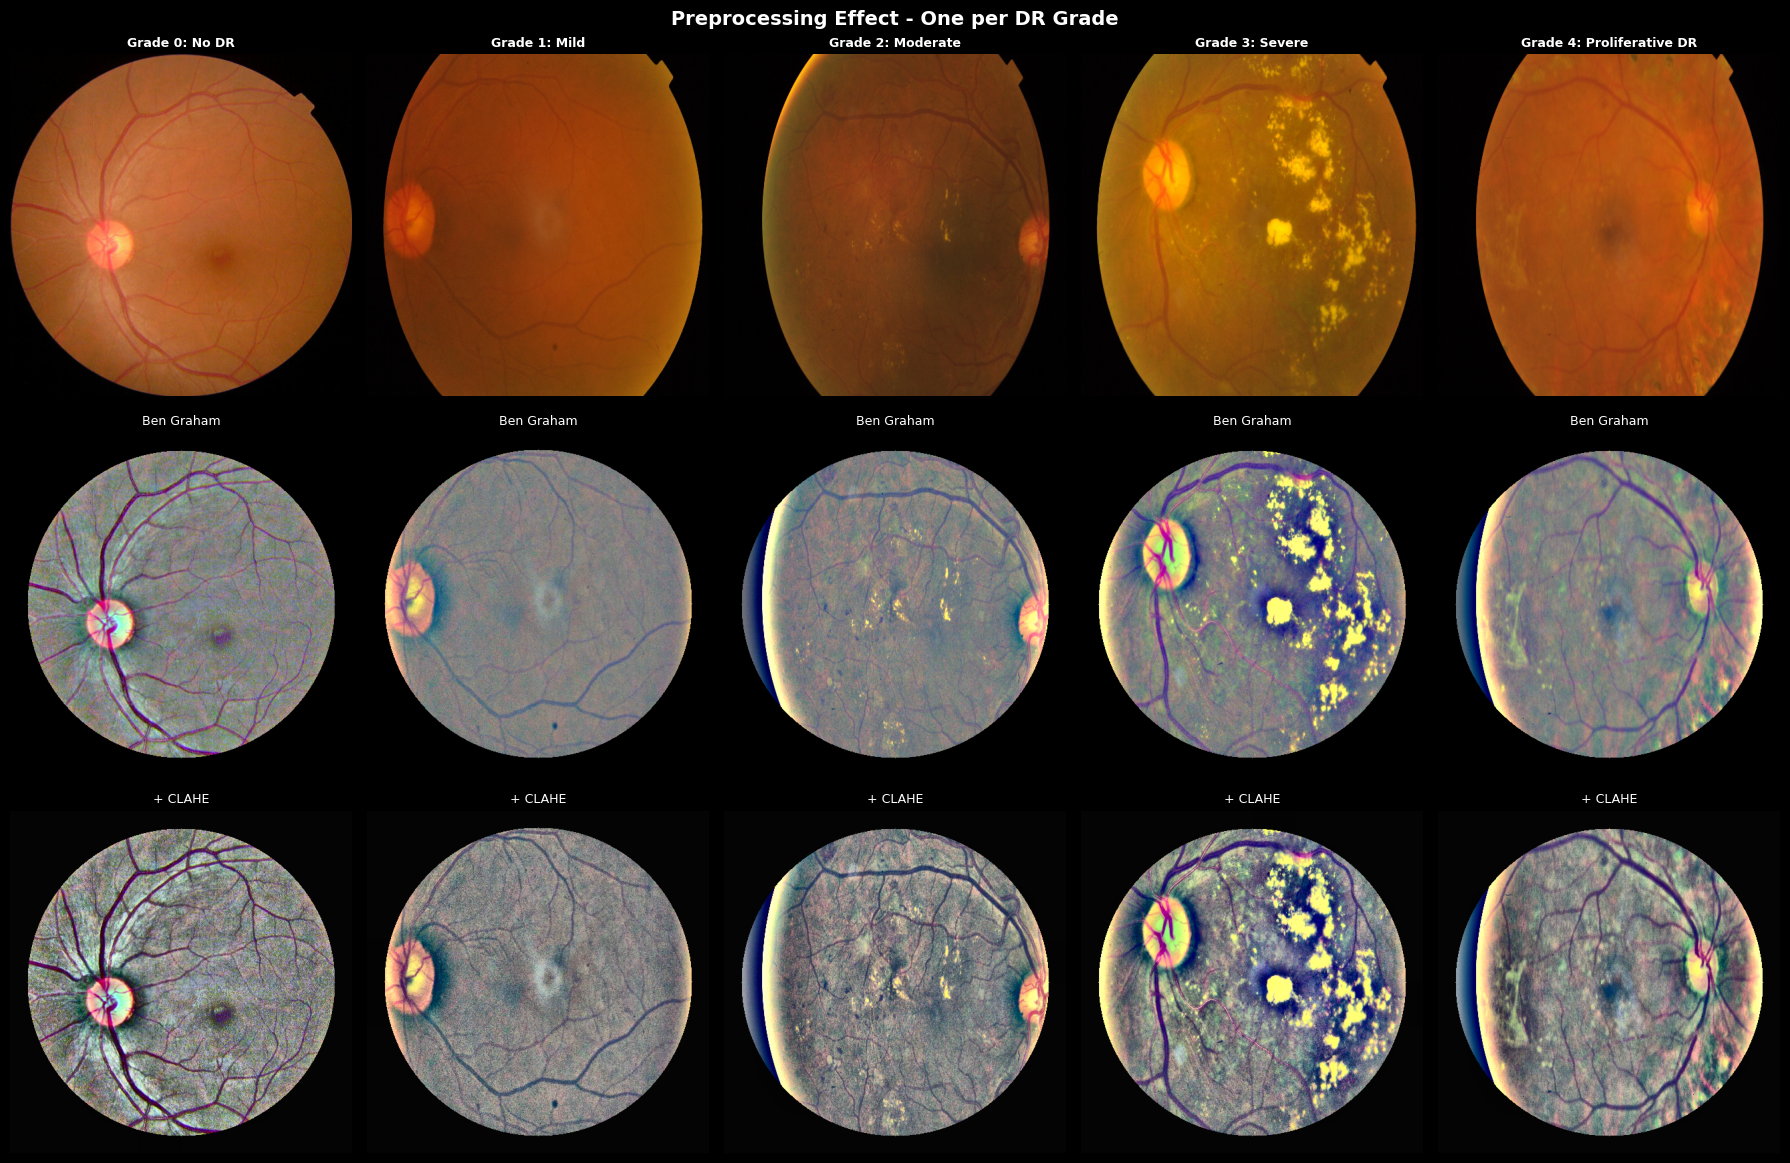

In [8]:
df = pd.read_csv(DATA_DIR / "train.csv")

fig, axes = plt.subplots(3, 5, figsize = (18, 12))
fig.suptitle("Preprocessing Effect - One per DR Grade", fontsize = 14, fontweight = 'bold')
CLASS_NAMES = {
    0: "No DR", 
    1: "Mild", 
    2: "Moderate", 
    3: "Severe", 
    4: "Proliferative DR"
}

for grade in range(5):
    sample = df[df['diagnosis'] == grade].iloc[0]['id_code']
    img_path = TRAIN_IMGS / f"{sample}.png"

    raw_img   = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    raw_img   = cv2.resize(raw_img, (512, 512))
    bg_img    = ben_graham_preprocess(img_path)
    full_img  = full_preprocess(img_path)

    axes[0][grade].imshow(raw_img)
    axes[0][grade].set_title(f"Grade {grade}: {CLASS_NAMES[grade]}", fontsize = 9, fontweight = 'bold')
    axes[0][grade].axis('off')

    axes[1][grade].imshow(bg_img)
    axes[1][grade].set_title("Ben Graham", fontsize = 9)
    axes[1][grade].axis('off')

    axes[2][grade].imshow(full_img)
    axes[2][grade].set_title("+ CLAHE", fontsize = 9)
    axes[2][grade].axis('off')

axes[0][0].set_ylabel("Original", fontsize = 11, labelpad = 10)
axes[1][0].set_ylabel("Ben Graham", fontsize = 11, labelpad = 10)
axes[2][0].set_ylabel("Ben Graham + CLAHE", fontsize = 11, labelpad = 10)

plt.tight_layout()
plt.savefig("preprocessing_comparison.png", dpi = 150, bbox_inches = 'tight')
plt.show()

In [9]:
from collections import Counter
import torch

counts = df['diagnosis'].value_counts().sort_index()
total = len(df)

# Inverse frequency weighting
class_weights = torch.tensor(
    [total / (5 * counts[i]) for i in range(5)],
    dtype = torch.float32
)

print("Class weights (higher = rarer class gets more attention):")
for i, w in enumerate(class_weights):
    print(f"Grade {i} ({CLASS_NAMES[i]}): {w:.3f}")

# Save for training
torch.save(class_weights, "class_weights.pt")

Class weights (higher = rarer class gets more attention):
Grade 0 (No DR): 0.406
Grade 1 (Mild): 1.979
Grade 2 (Moderate): 0.733
Grade 3 (Severe): 3.795
Grade 4 (Proliferative DR): 2.483


In [14]:
IMG_SIZE = 512

train_transforms = A.Compose(
    [
        A.Resize(IMG_SIZE, IMG_SIZE),

        # Geometric augmentations (retina can appear at any orientation)
        A.HorizontalFlip(p = 0.5),
        A.VerticalFlip(p = 0.5),
        A.RandomRotate90(p = 0.5),
        A.Affine(
            translate_percent = 0.1,
            scale = (0.85, 1.15),
            rotate = (-180, 180),
            border_mode = cv2.BORDER_CONSTANT,
            p = 0.7
        ),
        
        # Color augmentations (handle different fundus camera types)
        A.RandomBrightnessContrast(
            brightness_limit = 0.2,
            contrast_limit = 0.2, 
            p = 0.5
        ),
        
        A.HueSaturationValue(
            hue_shift_limit = 10,
            sat_shift_limit = 20,
            val_shift_limit = 10, 
            p = 0.4
        ),
        
        # Simulate different image quality levels
        A.OneOf(
            [
                A.GaussianBlur(blur_limit = (3, 5)),
                A.MedianBlur(blur_limit = 3),
                A.MotionBlur(blur_limit = 5),
            ], 
            p = 0.3
        ),
        
        # Simulate lesion-occlusion + regularization
        A.CoarseDropout(
            num_holes_range = (1, 8),
            hole_height_range = (16, 32),
            hole_width_range = (16, 32),
            fill = 0,
            p = 0.3
        ),
        
        # Normalize with ImageNet stats (for pretrained models)
        A.Normalize(
            mean = [0.485, 0.456, 0.406],
            std = [0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ]
)

val_transforms = A.Compose(
    [
        # Val: NO random augmentation — only resize + normalize
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(
            mean = [0.485, 0.456, 0.406],
            std = [0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ]
)

In [13]:
class RetinalDataset(Dataset):
    def __init__(self, df, img_dir, transform = None, preprocess = True):
        self.df         = df.reset_index(drop = True)
        self.img_dir    = Path(img_dir)
        self.transform  = transform
        self.preprocess = preprocess  # Ben Graham + CLAHE

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.img_dir / f"{row['id_code']}.png"

        if self.preprocess:
            img = full_preprocess(img_path, img_size = 512)
        else:
            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (512, 512))

        if self.transform:
            augmented = self.transform(image = img)
            img = augmented['image']

        label = int(row['diagnosis'])
        return img, label

    def get_sample_image(self, idx):
        """Return preprocessed PIL image for visualization (no tensor)"""
        row      = self.df.iloc[idx]
        img_path = self.img_dir / f"{row['id_code']}.png"
        img      = full_preprocess(img_path)
        return img, int(row['diagnosis'])

In [15]:
train_df, val_df = train_test_split(
    df,
    test_size = 0.2,
    random_state = 42,
    stratify = df['diagnosis']
)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print(f"\nTrain class distribution:\n{train_df['diagnosis'].value_counts().sort_index()}")
print(f"\nVal class distribution:\n{val_df['diagnosis'].value_counts().sort_index()}")

train_dataset = RetinalDataset(
    train_df,
    TRAIN_IMGS,
    transform = train_transforms,
    preprocess = True
)

val_dataset = RetinalDataset(
    val_df,
    TRAIN_IMGS,
    transform = val_transforms,
    preprocess = True
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 16,
    shuffle = True,
    num_workers = 2,
    pin_memory = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 16,
    shuffle = True,
    num_workers = 2,
    pin_memory = True
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train: 2929 | Val: 733

Train class distribution:
diagnosis
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

Val class distribution:
diagnosis
0    361
1     74
2    200
3     39
4     59
Name: count, dtype: int64

Train batches: 184
Val batches: 46


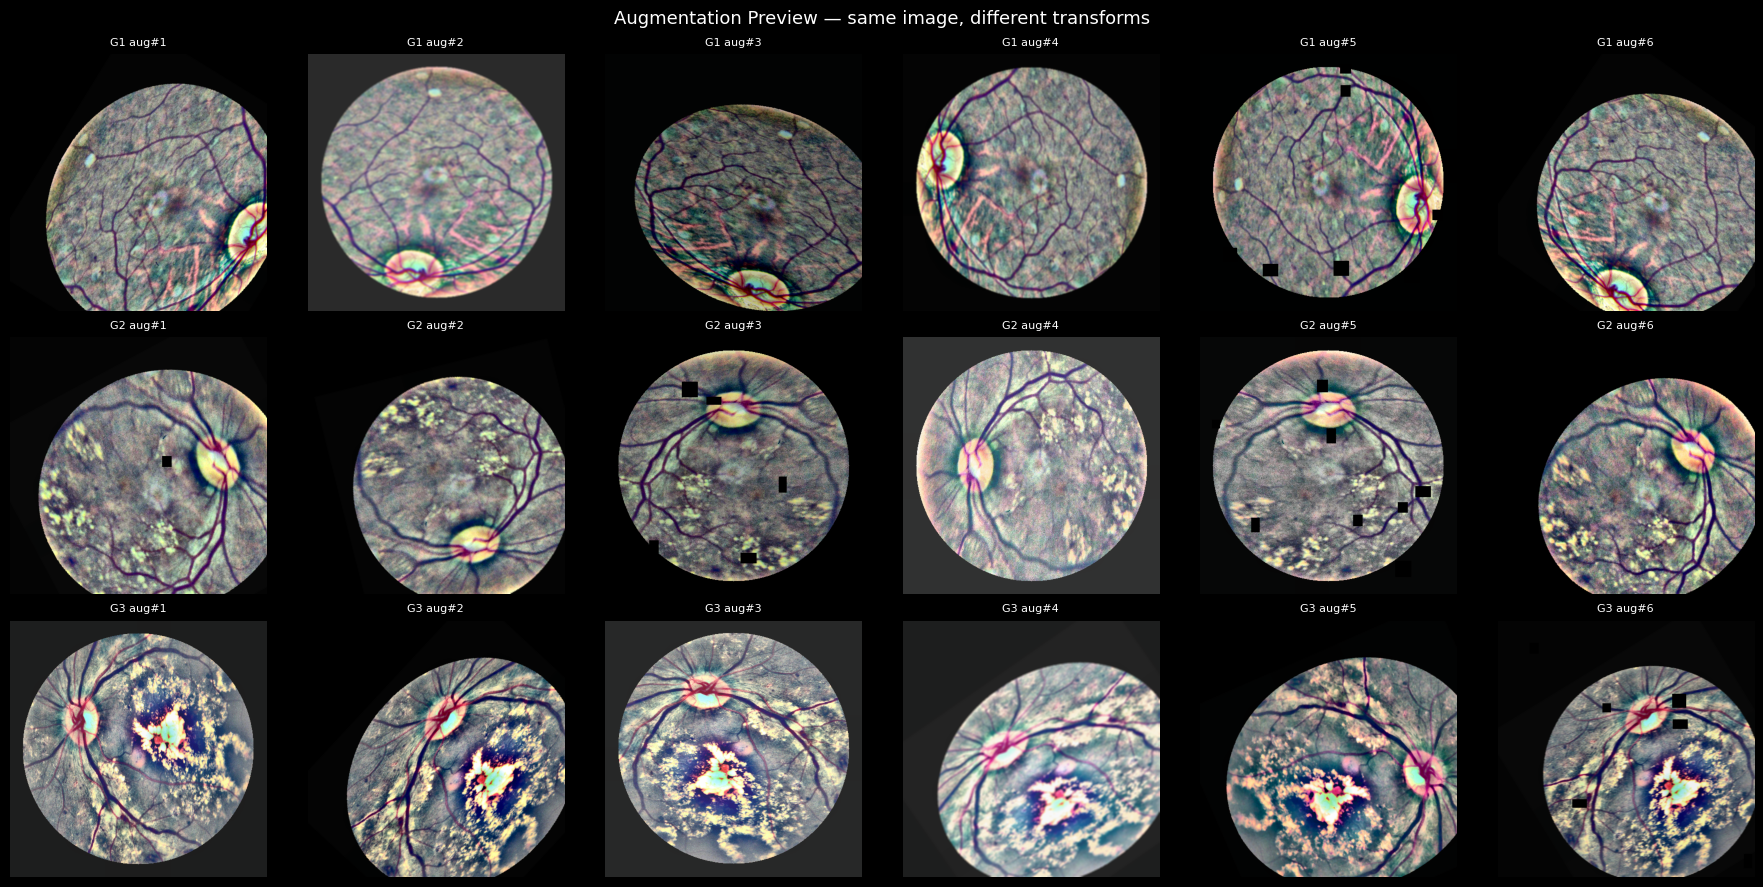

Augmentation pipeline verified!


In [16]:
import torchvision.transforms.functional as TF

fig, axes = plt.subplots(3, 6, figsize = (18, 9))
fig.suptitle("Augmentation Preview — same image, different transforms", fontsize = 13)

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

# Pick a Grade 2 sample (most visually interesting)
grade2_idx = train_df[train_df['diagnosis'] == 2].index[0]
local_idx  = train_df.index.get_loc(grade2_idx)

for col in range(6):
    for row_idx in range(3):
        grade = row_idx + 1
        g_idx = train_df[train_df['diagnosis'] == grade].index[0]
        l_idx = train_df.index.get_loc(g_idx)

        img_tensor, label = train_dataset[l_idx]
        # De-normalize for display
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = (img_np * STD + MEAN).clip(0, 1)

        axes[row_idx][col].imshow(img_np)
        axes[row_idx][col].set_title(f"G{label} aug#{col+1}", fontsize = 8)
        axes[row_idx][col].axis('off')

plt.tight_layout()
plt.savefig("augmentation_preview.png", dpi = 150, bbox_inches = 'tight')
plt.show()
print("Augmentation pipeline verified!")

In [17]:
imgs, labels = next(iter(train_loader))
print(f"Batch shape:  {imgs.shape}")      
print(f"Labels shape: {labels.shape}")   
print(f"Dtype:        {imgs.dtype}")      
print(f"Label range:  {labels.min()}-{labels.max()}")
print(f"Pixel range:  {imgs.min():.3f} to {imgs.max():.3f}")
print("\nPhase 2 complete — DataLoader is production-ready!")

Batch shape:  torch.Size([16, 3, 512, 512])
Labels shape: torch.Size([16])
Dtype:        torch.float32
Label range:  0-3
Pixel range:  -2.118 to 2.640

Phase 2 complete — DataLoader is production-ready!
